In [1]:
# Load library
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [2]:
# Loading HMC results

# Positive-Negative 
PN=np.load("./hmc_samples_10001_b1_0.5_b2_-0.8.npy")

# Negative-Negative
NN=np.load("./hmc_samples_10001_b1_-1.5_b2_-1.8.npy")

# Negative-Positive
NP=np.load("./hmc_samples_10001_b1_-1.5_b2_1.8.npy")

# Positive-Positive
PP=np.load("./hmc_samples_10001_b1_1.2_b2_1.8.npy")

In [3]:
Nchains = 4
Nsamples = 10000
Params = 2
PN=np.reshape(PN,(Nchains, Nsamples, Params))

#############  Positive- Negative coefficients ###################

# Calculate the within-chain variance
Cmeans = np.mean(PN, axis=1)
Cvars = np.mean(np.square(
    PN -np.expand_dims(
    Cmeans, axis=1)), axis=1)

# Calculate the between-chain variance
Total_mean = np.mean(Cmeans, axis=0)
btn_Cvar = np.sum(np.square(
      Cmeans - Total_mean), axis=0) / (Nchains - 1)

# Calculate the estimated variance of the target distribution
Varhat = (Nsamples - 1) / Nsamples * np.mean(
     Cvars, axis=0) + btn_Cvar

# Calculate potential scale reduction factor (R-hat)
Rhat = np.sqrt(Varhat / np.mean(Cvars, axis=0))

print("Rhat=",Rhat)

Rhat= [1.0001205 1.0000304]


In [4]:
#############  Negative- Negative coefficients ###################
NN=np.reshape(NN,(Nchains, Nsamples, Params))
# Calculate the within-chain variance
Cmeans = np.mean(NN, axis=1)
Cvars = np.mean(np.square(
    NN -np.expand_dims(
    Cmeans, axis=1)), axis=1)

# Calculate the between-chain variance
Total_mean = np.mean(Cmeans, axis=0)
btn_Cvar = np.sum(np.square(
      Cmeans - Total_mean), axis=0) / (Nchains - 1)

# Calculate the estimated variance of the target distribution
Varhat = (Nsamples - 1) / Nsamples * np.mean(
     Cvars, axis=0) + btn_Cvar

# Calculate potential scale reduction factor (R-hat)
Rhat = np.sqrt(Varhat / np.mean(Cvars, axis=0))

print("Rhat=",Rhat)

Rhat= [1.0000526 0.9999634]


In [5]:
#############  Negative- Positive coefficients ###################
NP=np.reshape(NP,(Nchains, Nsamples, Params))
# Calculate the within-chain variance
Cmeans = np.mean(NP, axis=1)
Cvars = np.mean(np.square(
    NP -np.expand_dims(
    Cmeans, axis=1)), axis=1)

# Calculate the between-chain variance
Total_mean = np.mean(Cmeans, axis=0)
btn_Cvar = np.sum(np.square(
      Cmeans - Total_mean), axis=0) / (Nchains - 1)

# Calculate the estimated variance of the target distribution
Varhat = (Nsamples - 1) / Nsamples * np.mean(
     Cvars, axis=0) + btn_Cvar

# Calculate potential scale reduction factor (R-hat)
Rhat = np.sqrt(Varhat / np.mean(Cvars, axis=0))

print("Rhat=",Rhat)

Rhat= [1.0003381 0.999982 ]


In [6]:
#############  Positive- Positive coefficients ###################
PP=np.reshape(PP,(Nchains, Nsamples, Params))
# Calculate the within-chain variance
Cmeans = np.mean(PP, axis=1)
Cvars = np.mean(np.square(
    PP -np.expand_dims(
    Cmeans, axis=1)), axis=1)

# Calculate the between-chain variance
Total_mean = np.mean(Cmeans, axis=0)
btn_Cvar = np.sum(np.square(
      Cmeans - Total_mean), axis=0) / (Nchains - 1)

# Calculate the estimated variance of the target distribution
Varhat = (Nsamples - 1) / Nsamples * np.mean(
     Cvars, axis=0) + btn_Cvar

# Calculate potential scale reduction factor (R-hat)
Rhat = np.sqrt(Varhat / np.mean(Cvars, axis=0))

print("Rhat=",Rhat)

Rhat= [1.0002441 0.9999959]


In [7]:
# Geweke diagnostic for convergence assessment of HMC chains.
def geweke_diagnostic(chain, first=0.1, last=0.5, intervals=20):
    Nchains, Nsamples, Nparameters = chain.shape
    first = int(first * Nsamples)
    last = int(last * Nsamples)
    z_scores = np.zeros((Nchains, Nparameters))
    p_values = np.zeros((Nchains, Nparameters))

    for i in range(Nchains):
        chain_i = chain[i]
        z_scores_i = np.zeros(Nparameters)
        p_values_i = np.zeros(Nparameters)
        for j in range(Nparameters):
            means_first = [np.mean(chain_i[:first, j]) for first in np.linspace(
                0.1 * Nsamples, 0.5 * Nsamples,intervals).astype(int)]
            
            means_last = [np.mean(chain_i[-last:, j]) for last in np.linspace(
                0.1 * Nsamples, 0.5 * Nsamples,intervals).astype(int)]
            
            z_scores_i[j] = (np.mean(means_first) - np.mean(means_last)) / np.sqrt(
                np.var(means_first) + np.var(means_last))
            
            p_values_i[j] = 2 * (1 - norm.cdf(np.abs(z_scores_i[j])))
            
        z_scores[i] = z_scores_i
        p_values[i] = p_values_i

    return z_scores, p_values


In [8]:
# Fit the function to perform geweke diagnostics
PNZ_scores,PNP_values=geweke_diagnostic(PN)#Positive-negative
NNZ_scores,NNP_values=geweke_diagnostic(NN)#Negative-negative
NPZ_scores,NPP_values=geweke_diagnostic(NP)#Negative-positive
PPZ_scores,PPP_values=geweke_diagnostic(PP)#Positive-Positive

/tmp/ipykernel_188/3576837048.py:71: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


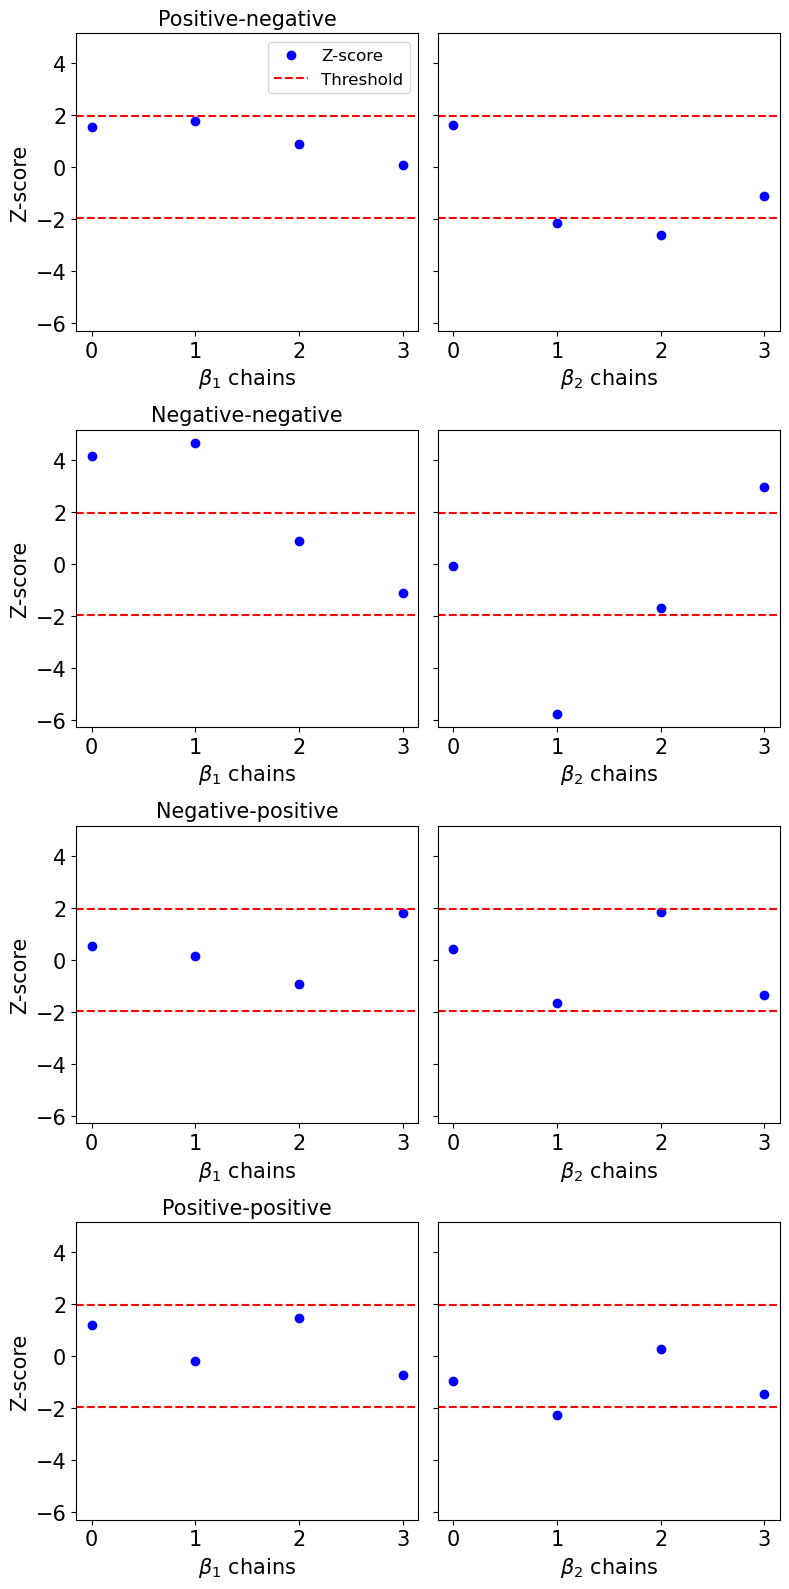

In [9]:
fig, ax=plt.subplots(4,2,figsize=(8,16),constrained_layout=True,sharey=True)

# Positive-negative
ax[0][0].plot(PNZ_scores[:,0],"o",color="blue",label="Z-score")
ax[0][0].axhline(y=1.96, color='r', linestyle='--', label='Threshold')
ax[0][0].axhline(y=-1.96, color='r', linestyle='--')
ax[0][0].tick_params(axis='both', which='major', labelsize=15)
ax[0][0].set_ylabel('Z-score',size=15)
ax[0][0].set_xlabel(r"$\beta_1$ chains",size=15)
ax[0][0].set_title("Positive-negative",size=15)
ax[0][0].legend(fontsize=12)

ax[0][1].plot(PNZ_scores[:,1],"o",color="blue")
ax[0][1].axhline(y=1.96, color='r', linestyle='--')
ax[0][1].axhline(y=-1.96, color='r', linestyle='--')
ax[0][1].set_ylabel('')
ax[0][1].set_xlabel(r"$\beta_2$ chains",size=15)
ax[0][1].tick_params(axis='both', which='major', labelsize=15)

# Negative-negative
ax[1][0].plot(NNZ_scores[:,0],"o",color="blue")
ax[1][0].axhline(y=1.96, color='r', linestyle='--')
ax[1][0].axhline(y=-1.96, color='r', linestyle='--')
ax[1][0].set_ylabel('Z-score',size=15)
ax[1][0].set_title("Negative-negative",size=15)
ax[1][0].set_xlabel(r"$\beta_1$ chains",size=15)
ax[1][0].tick_params(axis='both', which='major', labelsize=15)


ax[1][1].plot(NNZ_scores[:,1],"o",color="blue")
ax[1][1].axhline(y=1.96, color='r', linestyle='--')
ax[1][1].axhline(y=-1.96, color='r', linestyle='--')
ax[1][1].set_ylabel('')
ax[1][1].set_xlabel(r"$\beta_2$ chains",size=15)
ax[1][1].tick_params(axis='both', which='major', labelsize=15)

# Negative-positive
ax[2][0].plot(NPZ_scores[:,0],"o",color="blue")
ax[2][0].axhline(y=1.96, color='r', linestyle='--')
ax[2][0].axhline(y=-1.96, color='r', linestyle='--')
ax[2][0].set_ylabel('Z-score',size=15)
ax[2][0].set_title("Negative-positive",size=15)
ax[2][0].set_xlabel(r"$\beta_1$ chains",size=15)
ax[2][0].tick_params(axis='both', which='major', labelsize=15)

ax[2][1].plot(NPZ_scores[:,1],"o",color="blue")
ax[2][1].axhline(y=1.96, color='r', linestyle='--')
ax[2][1].axhline(y=-1.96, color='r', linestyle='--')
ax[2][1].set_ylabel('')
ax[2][1].set_xlabel(r"$\beta_2$ chains",size=15)
ax[2][1].tick_params(axis='both', which='major', labelsize=15)

# Positive-positive
ax[3][0].plot(PPZ_scores[:,0],"o",color="blue")
ax[3][0].axhline(y=1.96, color='r', linestyle='--')
ax[3][0].axhline(y=-1.96, color='r', linestyle='--')
ax[3][0].set_ylabel('Z-score',size=15)
ax[3][0].set_title("Positive-positive",size=15)
ax[3][0].set_xlabel(r"$\beta_1$ chains",size=15)
ax[3][0].tick_params(axis='both', which='major', labelsize=15)


ax[3][1].plot(PPZ_scores[:,1],"o",color="blue")
ax[3][1].axhline(y=1.96, color='r', linestyle='--')
ax[3][1].axhline(y=-1.96, color='r', linestyle='--')
ax[3][1].set_ylabel('')
ax[3][1].set_xlabel(r"$\beta_2$ chains",size=15)
ax[3][1].tick_params(axis='both', which='major', labelsize=15)


plt.tight_layout()
plt.show()